In [2]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import dill
import json
import sys
import os
from scipy import spatial
import matplotlib.pyplot as plt
import pickle

In [3]:
dict_path = 'data/reshaped_ev_points.csv'
ev_points = pd.read_csv(dict_path)
cluster = np.unique(ev_points['cluster'].values)
with open("/home/csartor1/code/NODS/network_configuration.json", "r") as json_file:
    net_config = json.load(json_file)
CS_burst_dur = net_config["devices"]["CS"]["parameters"]["burst_dur"]
CS_start_first = float(net_config["devices"]["CS"]["parameters"]["start_first"])
between_start = net_config["devices"]["CS"]["parameters"]["between_start"]
n_trials = net_config["devices"]["CS"]["parameters"]["n_trials"]
US_start_first = float(net_config["devices"]["US"]["parameters"]["start_first"])
CS_color = net_config["colors"]["CS"]
US_color = net_config["colors"]["US"]

In [4]:
rand_clusters = cluster
#rand_clusters = [71,80,106]
clusters_df = ev_points[ev_points['cluster'].isin(rand_clusters)]
ev_points_n_clusters = clusters_df[['ev_points_id', 'x', 'y', 'z']].values
#ev_points_n_clusters = ev_points[['ev_points_id', 'x', 'y', 'z']].values


In [5]:
t0 = 0
tf = 2000

In [6]:
file_path = '/home/csartor1/code/NODS/data/pfs-PC_CS_40.pkl'
with open(file_path, 'rb') as file:
    id_granule = pickle.load(file)
    file.close()

rel_dist_path = '/home/csartor1/code/NODS/data/relative_dist.csv'
# source_id, nos_id, ev_points_id, d, cluster
relative_dist = pd.read_csv(rel_dist_path, header = None)
matched_grc = relative_dist[relative_dist.iloc[:,1].isin(id_granule)]
id_ev = np.unique(matched_grc.iloc[:,3])

In [7]:
len(id_ev)

51022

In [8]:
result_path = 'results/test/w_NO/0Hz/sim_NO_conc_CS/NO_concentration_data/'

concentration_data_CS = []

for i in range(t0,tf,5):
    file_path = os.path.join(result_path,f'NO_concentration_t_{i}.csv')
    df_conc = pd.read_csv(file_path)
    matched_conc = df_conc[df_conc.iloc[:, 1].isin(id_ev)]
    concentrations = matched_conc.iloc[:, 2].values
    concentration_data_CS.append(concentrations)
    
concentration_data_CS = np.stack(concentration_data_CS,axis=0)
median_CS = np.median(concentration_data_CS,axis=1)

KeyboardInterrupt: 

In [42]:
max(median_CS)

np.float64(38.895527735798254)

In [23]:
max_value_index = np.argmax(concentration_data_CS)
# Get the row and column index of the max value
row, col = np.unravel_index(max_value_index, concentration_data_CS.shape)
concentration_plot_CS = concentration_data_CS[:,col]
concentration_data_CS[row,col]

np.float64(229.8113070026833)

In [ ]:
result_path = 'results/test/w_NO/12Hz/sim_NO_conc_CS/NO_concentration_data/'
concentration_data_noise = []

for i in range(t0,tf,5):
    file_path = os.path.join(result_path,result_path,f'NO_concentration_t_{i}.csv')
    df_conc = pd.read_csv(file_path)
    #matched_conc = df_conc[~df_conc.iloc[:, 1].isin(id_ev)]
    matched_conc = df_conc[df_conc.iloc[:, 1].isin(id_ev)]
    concentrations = matched_conc.iloc[:, 2].values
    concentration_data_noise.append(concentrations)
    
concentration_data_noise = np.stack(concentration_data_noise, axis=0)
median_noise = np.median(concentration_data_noise,axis=1)

In [ ]:
concentration_data_noise = np.array(concentration_data_noise)
max_value_index = np.argmax(concentration_data_noise)

# Get the row and column index of the max value
#row, col = np.unravel_index(max_value_index, concentration_noise_clusters.shape)
concentration_plot_noise = concentration_data_noise[:,col]
concentration_data_noise[row,col]

np.float64(180.46908398161588)

In [8]:
NO_conc_CS = []
NO_median = []
noise_levels = [0, 4, 8]
for noise in noise_levels:    
    result_path = f'results/test/w_NO/{noise}Hz/sim_NO_conc_CS/NO_concentration_data/'

    concentration_CS_clusters = []

    for i in range(t0,tf,5):
        file_path = result_path + f'NO_concentration_t_{i}.csv'
        df_conc = pd.read_csv(file_path,header=None)
        matched_conc = df_conc[df_conc.iloc[:, 1].isin(id_ev)]
        concentrations = matched_conc.iloc[:, 2].values
        concentration_CS_clusters.append(concentrations)

    concentration_data_CS = np.array(concentration_CS_clusters)
    median_CS = np.median(concentration_data_CS,axis=1)

    NO_conc_CS.append(concentration_data_CS)
    NO_median.append(median_CS)

NO_conc_CS = np.array(NO_conc_CS)
NO_median = np.array(NO_median)

In [9]:
max_value_index = np.argmax(NO_conc_CS[0])

# Get the row and column index of the max value
row, col = np.unravel_index(max_value_index, concentration_data_CS.shape)
concentration_plot_CS = concentration_data_CS[:,col]
col = 5
concentration_data_CS[row,col]


np.float64(160.68420892112647)

In [10]:
threshold = 100

def sig(x, A=2, B=170, C=5):
    return A / (1 + np.exp(-(x - B) / C))


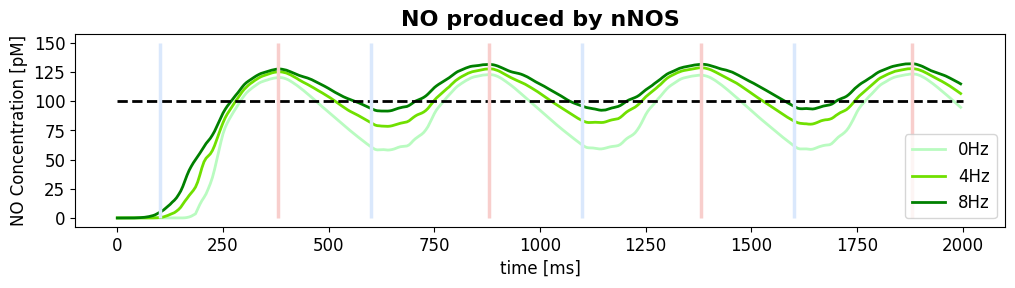

In [11]:
plt.rcParams.update({'font.size': 12},)
plt.figure(figsize=(12,2.5))
greens = ['#b9fbc0', '#70e000', '#008000', '#004225']
for i,noise in enumerate(noise_levels):
    
    plt.plot(np.arange(t0,tf,5),NO_median[i], linewidth=2, color = greens[i], label=f'{noise}Hz')

plt.xlabel('time [ms]')
plt.ylabel('NO Concentration [pM]')
plt.hlines(y = threshold, xmin = t0, xmax = tf,linestyles = 'dashed', linewidth=2, color = 'black')
plt.vlines([CS_start_first+t0+500*i for i in range(int(((tf-t0))/500))], ymin = 0, ymax = 150, linewidth=2.5, color=CS_color)
plt.vlines([CS_start_first + CS_burst_dur + t0 +500*i for i in range(int(((tf-t0))/500))], ymin = 0, ymax = 150, linewidth=2.5, color=US_color)
#plt.grid(visible=True)
plt.title('NO produced by nNOS', fontsize=16,fontweight ='bold')
plt.yticks([0,25,50,75,100,125,150])
plt.legend(loc = 'lower right')
#plt.savefig('vm_neuron.png')

plt.savefig('NO_trace_noises.png')
plt.show()

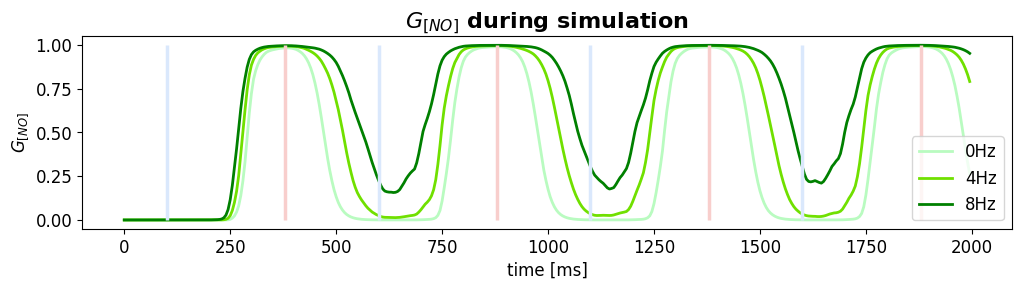

In [12]:
plt.rcParams.update({'font.size': 12},)
plt.figure(figsize=(12,2.5))
for i,noise in enumerate(noise_levels):
    median_GNO_CS= sig(x=NO_median[i], A=1, B=threshold)
    plt.plot(np.arange(t0,tf,5),median_GNO_CS, color = greens[i],linewidth=2, label=f'{noise}Hz')

plt.xlabel('time [ms]')
plt.ylabel('$G_{[NO]}$')
plt.vlines([CS_start_first+t0+500*i for i in range(int(((tf-t0))/500))], ymin = 0, ymax = 1, linewidth=2.5, color=CS_color)
plt.vlines([CS_start_first + CS_burst_dur + t0 +500*i for i in range(int(((tf-t0))/500))], ymin = 0, ymax = 1, linewidth=2.5, color=US_color)
#plt.grid(visible=True)
plt.title('$G_{[NO]}$ during simulation', fontsize=16,fontweight ='bold')
plt.legend(loc = 'lower right')
#plt.savefig('vm_neuron.png')

plt.savefig('GNO_trace_noises.png')
plt.show()

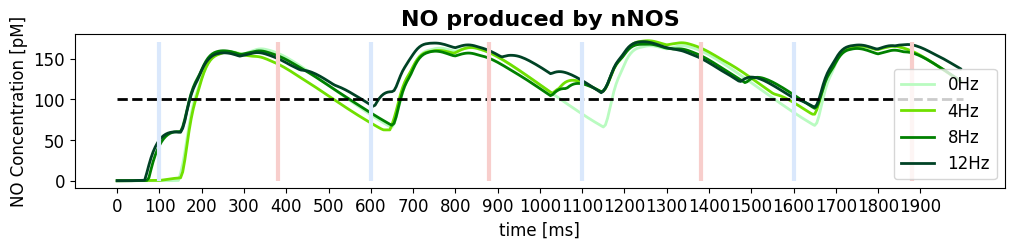

In [ ]:
plt.rcParams.update({'font.size': 12},)
plt.figure(figsize=(12,2))
for i,noise in enumerate([0,4,8,12]):
    plot_conc = NO_conc_CS[i,:,col]
    plt.plot(np.arange(t0,tf,5), plot_conc, color = greens[i],linewidth=2, label=f'{noise}Hz')

plt.xlabel('time [ms]')
plt.ylabel('NO Concentration [pM]')
plt.hlines(y = threshold, xmin = t0, xmax = tf,linestyles = 'dashed', linewidth=2, color = 'black')
plt.vlines([CS_start_first+t0+500*i for i in range(int(((tf-t0))/500))], ymin = 0, ymax = max(plot_conc), linewidth=2.5, color=CS_color)
plt.vlines([CS_start_first + CS_burst_dur + t0 +500*i for i in range(int(((tf-t0))/500))], ymin = 0, ymax = max(plot_conc), linewidth=3, color=US_color)
#plt.grid(visible=True)
plt.title('NO produced by nNOS', fontsize=16,fontweight ='bold')
plt.yticks(np.arange(0,max(plot_conc),50))
plt.xticks(np.arange(t0,tf,100))
plt.legend(loc = 'lower right')
#plt.savefig('vm_neuron.png')
plt.show()

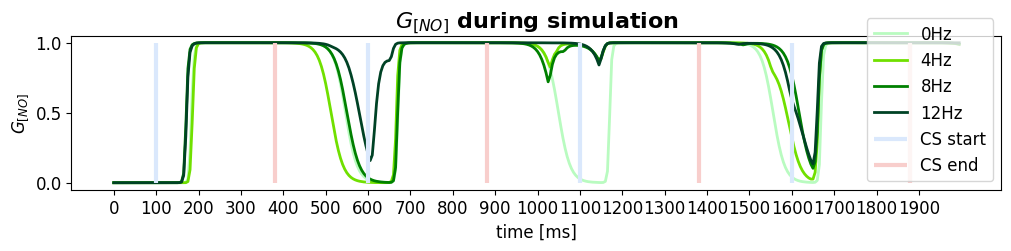

In [ ]:
plt.rcParams.update({'font.size': 12},)
plt.figure(figsize=(12,2))
for i,noise in enumerate([0,4,8,12]):
    plot_conc = NO_conc_CS[i,:,col]
    plt_GNO = sig(x=plot_conc, A=1, B=threshold)
    plt.plot(np.arange(t0,tf,5),plt_GNO, color = greens[i],linewidth=2, label=f'{noise}Hz')

plt.xlabel('time [ms]')
plt.ylabel('$G_{[NO]}$')
plt.vlines([CS_start_first+t0+500*i for i in range(int(((tf-t0))/500))], ymin = 0, ymax = 1, label="CS start", linewidth=3, color=CS_color)
plt.vlines([CS_start_first + CS_burst_dur + t0 +500*i for i in range(int(((tf-t0))/500))], ymin = 0, ymax = 1, label="CS end", linewidth=3, color=US_color)
#plt.grid(visible=True)
plt.title('$G_{[NO]}$ during simulation', fontsize=16,fontweight ='bold')
plt.legend(loc = 'lower right')
plt.xticks(np.arange(t0,tf,100))
#plt.savefig('vm_neuron.png')
plt.show()

In [13]:
NO_conc_noise = []
NO_median_noise = []
for noise in noise_levels:    
    result_path = f'results/test/w_NO/{noise}Hz/sim_NO_conc_CS/NO_concentration_data/'

    concentration_noise = []

    for i in range(t0,tf,5):
        file_path = result_path + f'NO_concentration_t_{i}.csv'
        df_conc = pd.read_csv(file_path,header=None)
        matched_conc = df_conc[~df_conc.iloc[:, 1].isin(id_ev)]
        concentrations = matched_conc.iloc[:, 2].values
        concentration_noise.append(concentrations)

    concentration_data_noise = np.array(concentration_noise)
    median_noise = np.median(concentration_data_noise,axis=1)

    NO_conc_noise.append(concentration_data_noise)
    NO_median_noise.append(median_noise)

NO_conc_noise= np.array(NO_conc_noise)
NO_median_noise = np.array(NO_median_noise)

In [14]:
median_GNO_noise = []
threshold = 100
for i,noise in enumerate(noise_levels):
    median_GNO_noise.append(sig(x=NO_median_noise[i], A=1, B=threshold))

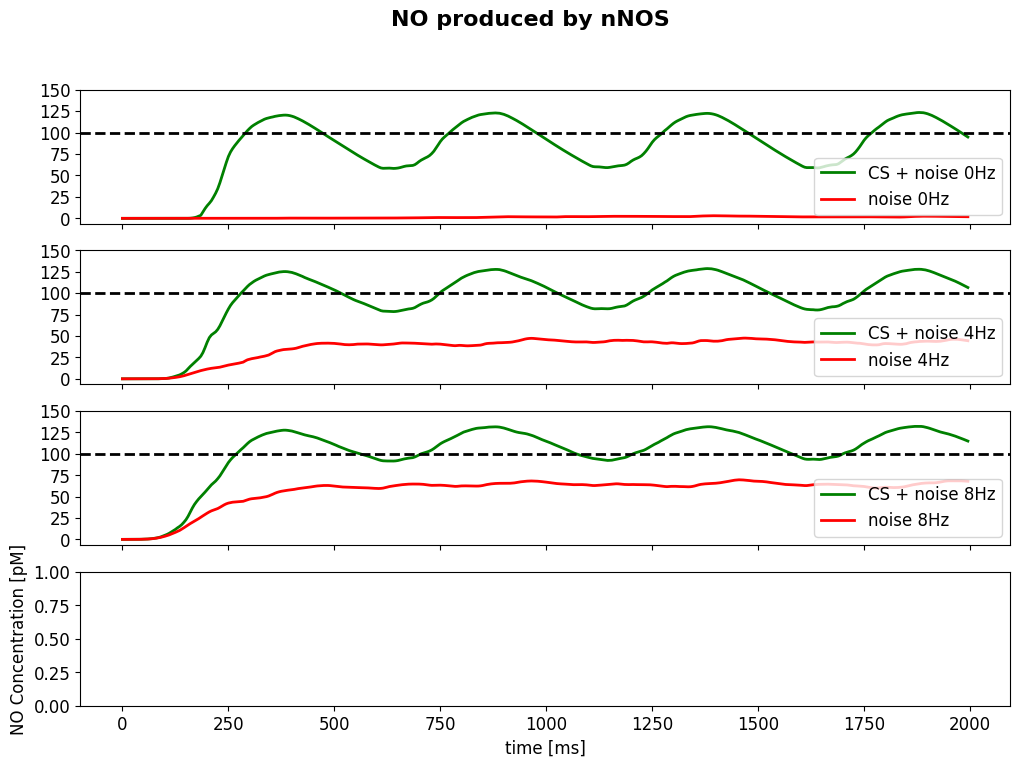

In [15]:
plt.rcParams.update({'font.size': 12},)
fig, axs = plt.subplots(4, 1, figsize=(12, 8), sharex = True)
for i,noise in enumerate(noise_levels):

    axs[i].plot(np.arange(t0,tf,5),NO_median[i], linewidth=2, color = 'g',label=f'CS + noise {noise}Hz')
    axs[i].plot(np.arange(t0,tf,5),NO_median_noise[i], linewidth=2, color = 'r',label=f'noise {noise}Hz')

    axs[i].axhline(y = threshold, xmin = t0, xmax = tf,linestyle = 'dashed', linewidth=2, color = 'black')
    #axs[i].axvline([CS_start_first+t0+500*j for j in range(int(((tf-t0))/500))], ymin = 0, ymax = 150, linewidth=3, color=CS_color)
    #axs[i].axvline([CS_start_first + CS_burst_dur + t0 +500*j for j in range(int(((tf-t0))/500))], ymin = 0, ymax = 150, linewidth=3, color=US_color)
    #plt.grid(visible=True)
    
    axs[i].set_yticks([0,25,50,75,100,125,150])
    axs[i].legend(loc = 'lower right')
    #plt.savefig('vm_neuron.png')
plt.suptitle('NO produced by nNOS', fontsize=16,fontweight ='bold')
plt.xlabel('time [ms]')
plt.ylabel('NO Concentration [pM]')
plt.show()

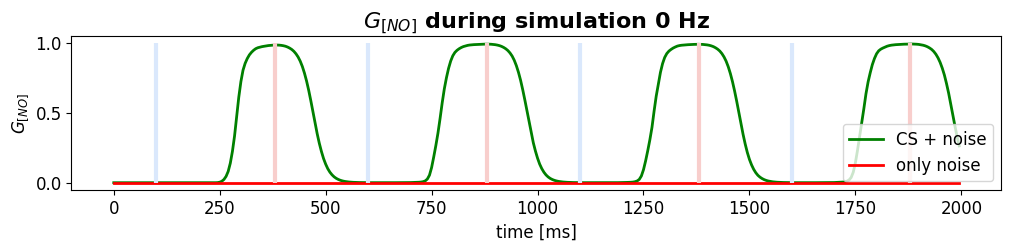

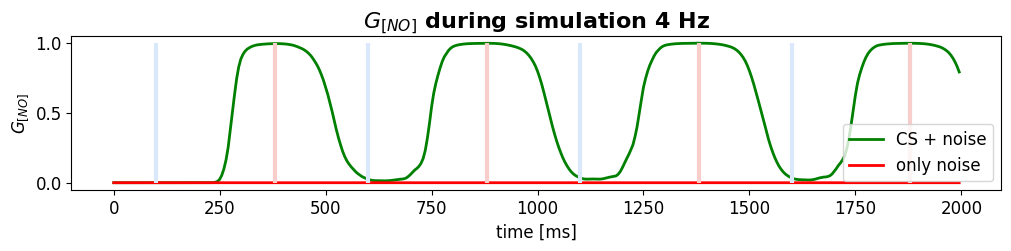

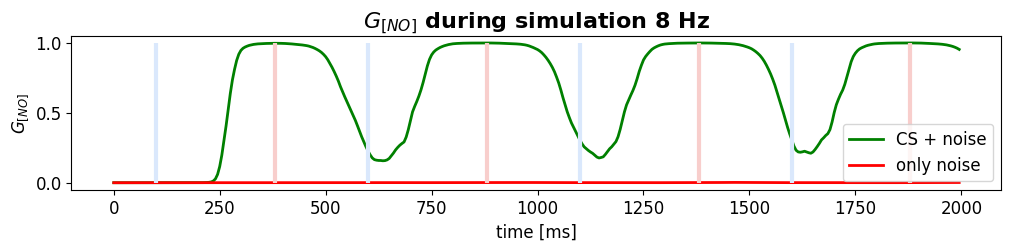

In [16]:
plt.rcParams.update({'font.size': 12},)

for i,noise in enumerate(noise_levels):
    plt.figure(figsize=(12,2))
    median_GNO_CS= sig(x=NO_median[i], A=1, B=threshold)
    median_GNO_noise= sig(x=NO_median_noise[i], A=1, B=threshold)
    plt.plot(np.arange(t0,tf,5),median_GNO_CS, color='g',linewidth=2, label=f'CS + noise')
    plt.plot(np.arange(t0,tf,5),median_GNO_noise, color='r',linewidth=2, label=f'only noise')

    plt.xlabel('time [ms]')
    plt.ylabel('$G_{[NO]}$')
    plt.vlines([CS_start_first+t0+500*i for i in range(int(((tf-t0))/500))], ymin = 0, ymax = 1, linewidth=3, color=CS_color)
    plt.vlines([CS_start_first + CS_burst_dur + t0 +500*i for i in range(int(((tf-t0))/500))], ymin = 0, ymax = 1, linewidth=3, color=US_color)
    #plt.grid(visible=True)
    plt.title('$G_{[NO]}$ during simulation'+f' {noise} Hz', fontsize=16,fontweight ='bold')
    plt.legend(loc = 'lower right')
    #plt.savefig('vm_neuron.png')
    plt.show()

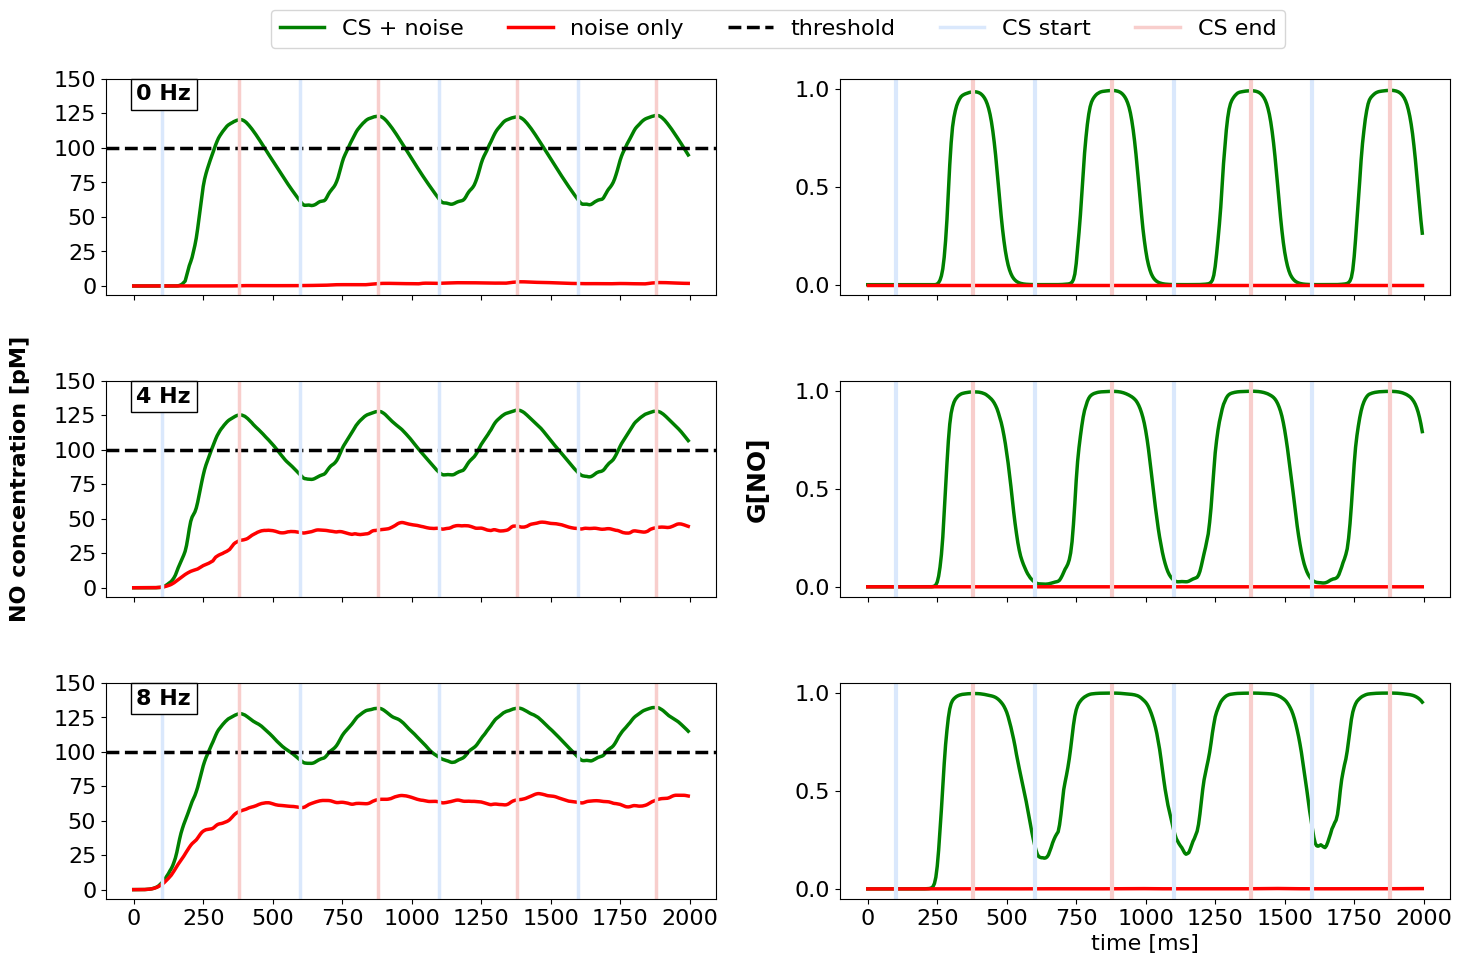

In [17]:
plt.rcParams.update({'font.size': 16})
fig, axs = plt.subplots(3, 2, figsize=(16, 10), sharex=True, gridspec_kw={'height_ratios': [3, 3, 3]})
fig.tight_layout(pad=3.0)



# Create the plots
for i, noise in enumerate(noise_levels):
    # Left column: NO concentration
    axs[i, 0].plot(np.arange(t0, tf, 5), NO_median[i], linewidth=2.5, color='g', label=f'CS + noise')
    axs[i, 0].plot(np.arange(t0, tf, 5), NO_median_noise[i], linewidth=2.5, color='r', label=f'noise only')
    axs[i, 0].axhline(y=threshold, xmin=0, xmax=1, linestyle='dashed', linewidth=2.5, color='black', label = 'threshold')
    axs[i, 0].set_yticks([0, 25, 50, 75, 100, 125, 150])
    
    # Add noise level text to the left plot
    axs[i, 0].text(0.05, 0.9, f'{noise} Hz', transform=axs[i, 0].transAxes, 
                 fontsize=16, fontweight='bold', bbox=dict(facecolor='white'))
    
    # Add vertical lines for CS and US in left column
    for j in range(int((tf-t0)/500)):
        axs[i, 0].axvline(x=CS_start_first+t0+500*j, ymin=0, ymax=1, linewidth=2.5, color=CS_color, label = 'CS start')
        axs[i, 0].axvline(x=CS_start_first+CS_burst_dur+t0+500*j, ymin=0, ymax=1, linewidth=2.5, color=US_color, label = 'CS end')
    
    if i == 3:  # Only add x-label on the bottom plot
        axs[i, 0].set_xlabel('time [ms]')
    
    # Right column: G[NO]
    median_GNO_CS = sig(x=NO_median[i], A=1, B=threshold)
    median_GNO_noise = sig(x=NO_median_noise[i], A=1, B=threshold)
    axs[i, 1].plot(np.arange(t0, tf, 5), median_GNO_CS, color='g', linewidth=2.5, label='CS + noise')
    axs[i, 1].plot(np.arange(t0, tf, 5), median_GNO_noise, color='r', linewidth=2.5, label='only noise')
    axs[i, 1].set_ylim(-0.05, 1.05)
    axs[i, 1].set_yticks([0, 0.5, 1])
    
    # Add vertical lines for CS and US in right column
    for j in range(int((tf-t0)/500)):
        axs[i, 1].axvline(x=CS_start_first+t0+500*j, ymin=0, ymax=1, linewidth=3, color=CS_color)
        axs[i, 1].axvline(x=CS_start_first+CS_burst_dur+t0+500*j, ymin=0, ymax=1, linewidth=3, color=US_color)
    
    if i == 2:  # Only add x-label on the bottom plot
        axs[i, 1].set_xlabel('time [ms]')
    
# Add bold labels for each column
#fig.text(0.25, 0.02, 'time [ms]', ha='center', fontsize=16, fontweight='bold')
#fig.text(0.75, 0.02, 'time [ms]', ha='center', fontsize=16, fontweight='bold')
fig.text(0.02, 0.5, 'NO concentration [pM]', va='center', fontsize=16, fontweight='bold', rotation=90)
fig.text(0.48, 0.5, 'G[NO]', va='center', fontsize=18, fontweight='bold', rotation=90)

# Add a legend to the figure (outside the plots)
lines1, labels1 = axs[0, 0].get_legend_handles_labels()
#lines2, labels2 = axs[0, 1].get_legend_handles_labels()
fig.legend(lines1[:5], labels1[:5], loc='upper center', ncol=5, bbox_to_anchor=(0.5, 0.98), frameon=True)

# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.4, left=0.08, right=0.92, top=0.9, bottom=0.08)

# Show the plot
plt.show()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

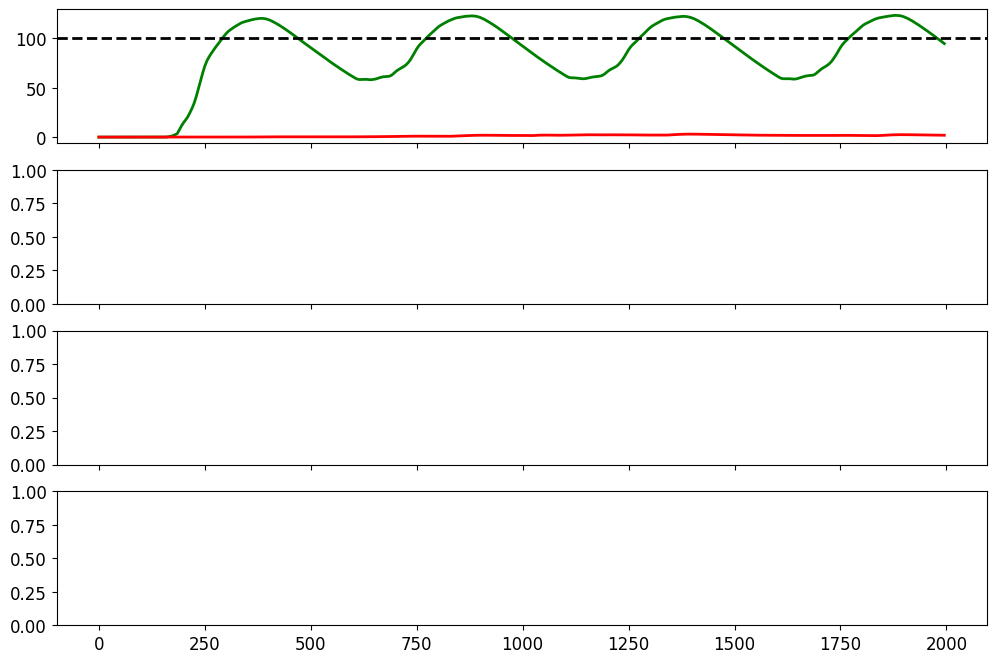

In [25]:
plt.rcParams.update({'font.size': 12},)
fig, axs = plt.subplots(4, 1, figsize=(12, 8), sharex = True)
for i,noise in enumerate([0,4,8,12]):

    axs[0].plot(np.arange(t0,tf,5),NO_median[i], linewidth=2, color = 'g',label=f'CS + noise {noise}Hz')
    axs[0].plot(np.arange(t0,tf,5),NO_median_noise[i], linewidth=2, color = 'r',label=f'noise {noise}Hz')

    axs[0].axhline(y = threshold, xmin = t0, xmax = tf,linestyle = 'dashed', linewidth=2, color = 'black')
    axs[i].axvline([CS_start_first+t0+500*j for j in range(int(((tf-t0))/500))], ymin = 0, ymax = 150, linewidth=3, color=CS_color)
    axs[i].axvline([CS_start_first + CS_burst_dur + t0 +500*j for j in range(int(((tf-t0))/500))], ymin = 0, ymax = 150, linewidth=3, color=US_color)
    
    axs[0].set_yticks([0,25,50,75,100,125,150])
    axs[0].legend(loc = 'lower right')
    axs[0].set_ylabel('NO Concentration [pM]')
    #plt.savefig('vm_neuron.png')
plt.suptitle('NO produced by nNOS', fontsize=16,fontweight ='bold')
plt.xlabel('time [ms]')

plt.show()

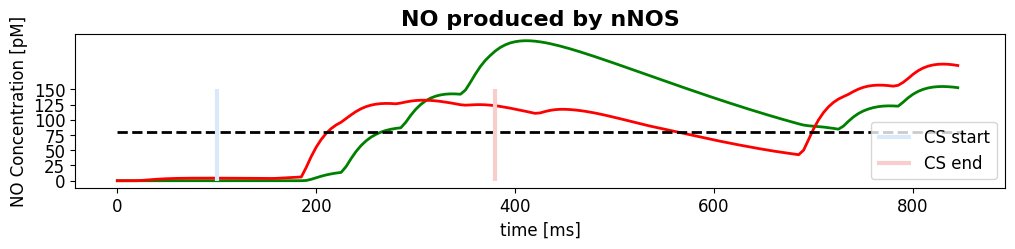

In [24]:
cs_GNO = sig(x=concentration_plot_CS, A=1, B=threshold)
noise_GNO = sig(x=concentration_plot_noise, A=1, B=threshold)

plt.rcParams.update({'font.size': 12},)
plt.figure(figsize=(12,2))
plt.plot(np.arange(t0,tf,5),concentration_plot_CS, 'g', linewidth=2)
plt.plot(np.arange(t0,tf,5),concentration_plot_noise, 'r', linewidth=2)
plt.xlabel('time [ms]')
plt.ylabel('NO Concentration [pM]')
plt.hlines(y = threshold, xmin = t0, xmax = tf,linestyles = 'dashed', linewidth=2, color = 'black')
plt.vlines([CS_start_first+t0+500*i for i in range(int(((tf-t0))/500))], ymin = 0, ymax = 150, label="CS start", linewidth=3, color=CS_color)
plt.vlines([CS_start_first + CS_burst_dur + t0 +500*i for i in range(int(((tf-t0))/500))], ymin = 0, ymax = 150, label="CS end", linewidth=3, color=US_color)
#plt.grid(visible=True)
plt.title('NO produced by nNOS', fontsize=16,fontweight ='bold')
plt.yticks([0,25,50,75,100,125,150])
plt.legend(loc = 'lower right')
#plt.savefig('vm_neuron.png')
plt.show()

In [17]:
cs_GNO = sig(x=concentration_plot_CS, A=1, B=threshold)
noise_GNO = sig(x=concentration_plot_noise, A=1, B=threshold)

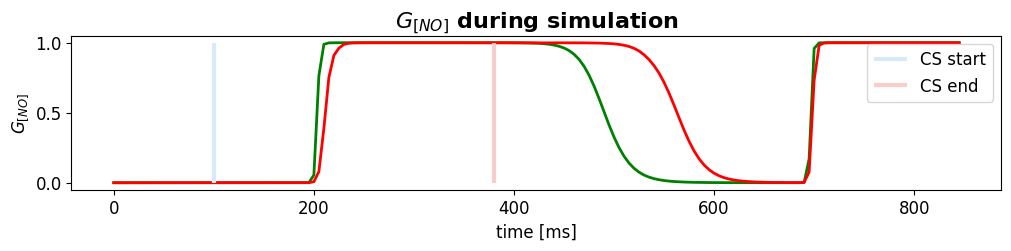

In [18]:
plt.rcParams.update({'font.size': 12},)
plt.figure(figsize=(12,2))
plt.plot(np.arange(t0,tf,5),cs_GNO, 'g', linewidth=2)
plt.plot(np.arange(t0,tf,5),noise_GNO, 'r', linewidth=2)
plt.xlabel('time [ms]')
plt.ylabel('$G_{[NO]}$')
plt.vlines([CS_start_first+t0 +500*i for i in range(int(((tf-t0))/500))], ymin = 0, ymax = 1, label="CS start", linewidth=3, color=CS_color)
plt.vlines([CS_start_first + CS_burst_dur + t0 +500*i for i in range(int(((tf-t0))/500))], ymin = 0, ymax = 1, label="CS end", linewidth=3, color=US_color)
plt.legend()
plt.title('$G_{[NO]}$ during simulation', fontsize=16,fontweight ='bold')
#plt.savefig('vm_neuron.png')
plt.show()

In [ ]:
CS_above_threshold = [np.sum(conc > threshold) for conc in concentration_CS_clusters]
noise_above_threshold = [np.sum(conc > threshold) for conc in concentration_noise_clusters]
CS_proportion = [np.mean(conc > threshold) for conc in concentration_CS_clusters]
noise_proportion = [np.mean(conc > threshold) for conc in concentration_noise_clusters]

In [22]:
normal_summary = {
    'mean': np.mean(CS_above_threshold),
    'std_dev': np.std(CS_above_threshold)
}
noise_summary = {
    'mean': np.mean(noise_above_threshold),
    'std_dev': np.std(noise_above_threshold)
}

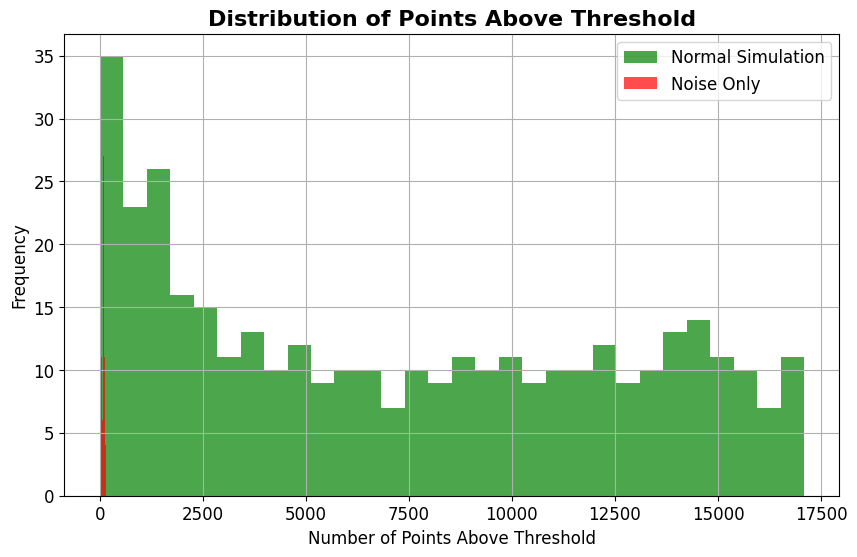

In [23]:
plt.rcParams.update({'font.size': 12},)
plt.figure(figsize=(10, 6))
plt.hist(CS_above_threshold, bins=30, alpha=0.7, label='Normal Simulation', color='g')
plt.hist(noise_above_threshold, bins=30, alpha=0.7, label='Noise Only', color='r')
#plt.axvline(x=threshold, color='red', linestyle='--', label='Threshold (130 pM)')
plt.xlabel('Number of Points Above Threshold')
plt.ylabel('Frequency')
plt.title('Distribution of Points Above Threshold', fontsize=16,fontweight ='bold')
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_1461197/3264598235.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([CS_above_threshold, noise_above_threshold], labels=['Normal', 'Noise Only'])


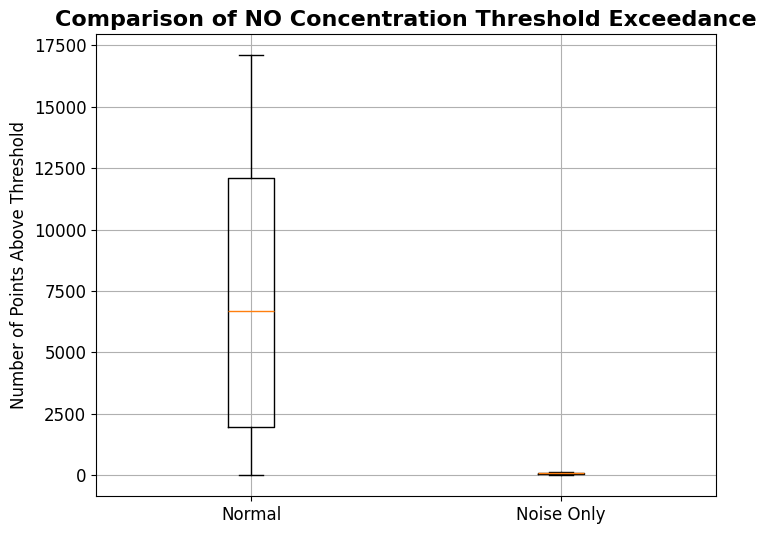

In [24]:
plt.figure(figsize=(8, 6))
plt.boxplot([CS_above_threshold, noise_above_threshold], labels=['Normal', 'Noise Only'])
plt.ylabel('Number of Points Above Threshold')
plt.title('Comparison of NO Concentration Threshold Exceedance', fontsize=16,fontweight ='bold')
plt.grid(True)
plt.show()

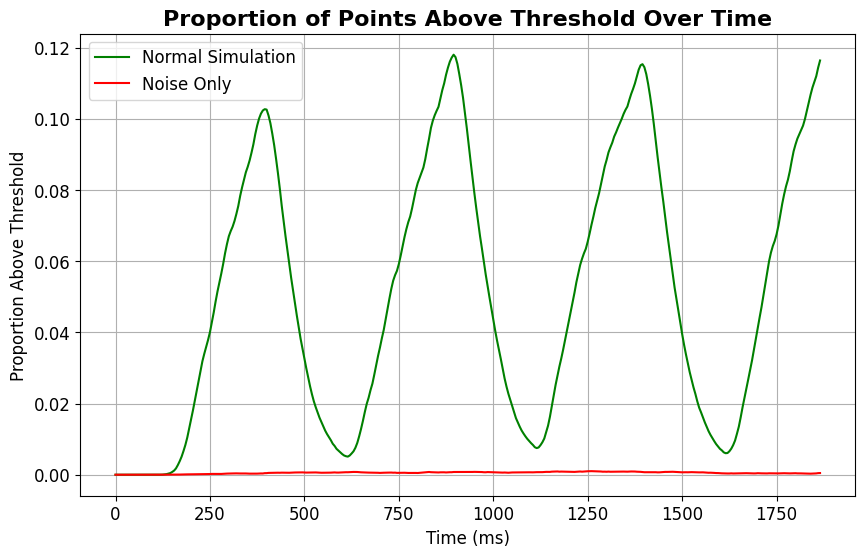

In [25]:
plt.rcParams.update({'font.size': 12},)
time = np.arange(t0, tf, 5) 
plt.figure(figsize=(10, 6))
plt.plot(time, CS_proportion, label='Normal Simulation', color='g')
plt.plot(time, noise_proportion, label='Noise Only', color='r')
#plt.axhline(y=0.5, color='red', linestyle='--', label='50% Proportion')
plt.xlabel('Time (ms)')
plt.ylabel('Proportion Above Threshold')
plt.title('Proportion of Points Above Threshold Over Time', fontsize=16,fontweight ='bold')
plt.legend()
plt.grid(True)
plt.show()

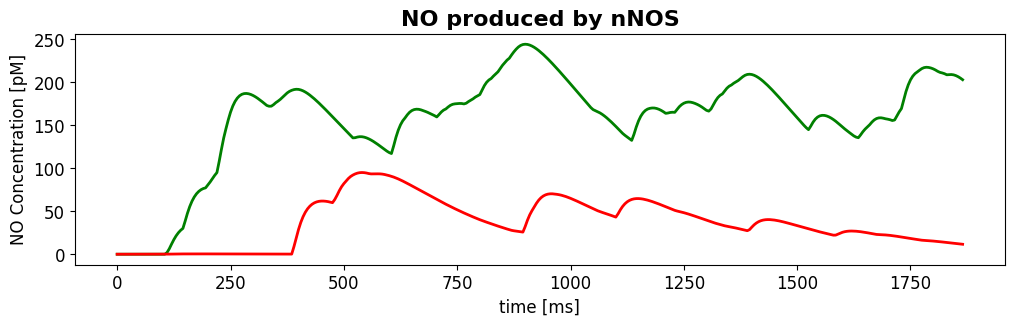

In [20]:
#plt.rcParams.update({'font.size': 12},)
plt.figure(figsize=(12,3))
plt.plot(np.arange(t0,tf,5),concentration_plot_CS, 'g', linewidth=2)
plt.plot(np.arange(t0,tf,5),concentration_plot_noise, 'r', linewidth=2)
plt.xlabel('time [ms]')
plt.ylabel('NO Concentration [pM]')
#plt.grid(visible=True)
plt.title('NO produced by nNOS', fontsize=16,fontweight ='bold')
#plt.savefig('vm_neuron.png')
plt.show()

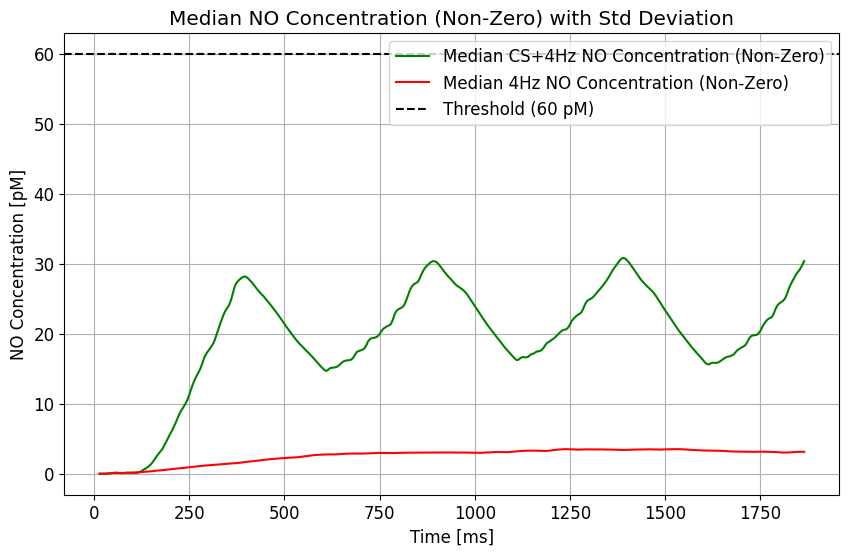

In [260]:
# Initialize lists for storing results
CS_filtered_median = []
CS_filtered_std = []
CS_filtered_time = []
noise_filtered_median = []
noise_filtered_std = []
noise_filtered_time = []

# Loop through each time point and compute stats
for i in range(concentration_CS_clusters.shape[0]):
    non_zero_values = concentration_CS_clusters[i][concentration_CS_clusters[i] > 0]  # Filter out zeros
    if len(non_zero_values) > 0:  # Only process if there are non-zero values
        CS_filtered_median.append(np.median(non_zero_values))  # Median of non-zero values
        CS_filtered_std.append(np.std(non_zero_values))        # Std of non-zero values
        CS_filtered_time.append(time[i])                      # Save corresponding time
    non_zero_values = concentration_noise_clusters[i][concentration_noise_clusters[i] > 0]  # Filter out zeros
    if len(non_zero_values) > 0:  # Only process if there are non-zero values
        noise_filtered_median.append(np.median(non_zero_values))  # Median of non-zero values
        noise_filtered_std.append(np.std(non_zero_values))        # Std of non-zero values
        noise_filtered_time.append(time[i])
# Convert lists to numpy arrays for plotting
CS_filtered_median = np.array(CS_filtered_median)
CS_filtered_std = np.array(CS_filtered_std)
CS_filtered_time = np.array(CS_filtered_time)

noise_filtered_median = np.array(noise_filtered_median)
noise_filtered_std = np.array(noise_filtered_std)
noise_filtered_time = np.array(noise_filtered_time)

step_size = 100 // 5  # Convert 50 ms to the number of steps
CS_downsampled_times = CS_filtered_time[::step_size]
CS_downsampled_std = CS_filtered_std[::step_size]

noise_downsampled_times = noise_filtered_time[::step_size]
noise_downsampled_std = noise_filtered_std[::step_size]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(CS_filtered_time, CS_filtered_median, label='Median CS+4Hz NO Concentration (Non-Zero)', color='green')
plt.plot(noise_filtered_time, noise_filtered_median, label='Median 4Hz NO Concentration (Non-Zero)', color='red')
plt.axhline(y=threshold, color='black', linestyle='--', label=f'Threshold ({threshold} pM)')

plt.xlabel('Time [ms]')
plt.ylabel('NO Concentration [pM]')
plt.title('Median NO Concentration (Non-Zero) with Std Deviation')
plt.legend()
plt.grid(True)
plt.show()

In [261]:
result_path = 'results/NO_concentration_data_CS_5ms_cycled_1/'
concentration_CS_clusters = []
for i in range(0,t,5):
    file_path = result_path + f'NO_concentration_t_{i}.csv'
    df_conc = pd.read_csv(file_path, header = None)
    matched_conc = df_conc[df_conc.iloc[:, 1].isin(ev_points_n_clusters[:, 0])]
    concentrations = matched_conc.iloc[:, 2].values
    #concentrations[concentrations<160] = 0
    #log_concentrations = np.log10(concentrations + epsilon)
    concentration_CS_clusters.append(concentrations)

In [262]:
concentration_CS_clusters = np.array(concentration_CS_clusters)
max_value_index = np.argmax(concentration_CS_clusters)

# Get the row and column index of the max value
row, col = np.unravel_index(max_value_index, concentration_CS_clusters.shape)
concentration_plot_CS = concentration_CS_clusters[:,col]
concentration_CS_clusters[row,col]

np.float64(411.5209079040204)

In [263]:
result_path = 'results/NO_concentration_data_noise_5ms_cycled_1/'
concentration_noise_clusters = []
for i in range(0,t,5):
    file_path = result_path + f'NO_concentration_t_{i}.csv'
    df_conc = pd.read_csv(file_path, header = None)
    matched_conc = df_conc[df_conc.iloc[:, 1].isin(ev_points_n_clusters[:, 0])]
    concentrations = matched_conc.iloc[:, 2].values
    #concentrations[concentrations<160] = 0
    #log_concentrations = np.log10(concentrations + epsilon)
    concentration_noise_clusters.append(concentrations)

In [264]:
concentration_noise_clusters = np.array(concentration_noise_clusters)
max_value_index = np.argmax(concentration_noise_clusters)

# Get the row and column index of the max value
row, col = np.unravel_index(max_value_index, concentration_noise_clusters.shape)
concentration_plot_noise = concentration_noise_clusters[:,col]
concentration_noise_clusters[row,col]

np.float64(216.6092116221987)

In [265]:
CS_above_threshold = [np.sum(conc > threshold) for conc in concentration_CS_clusters]
noise_above_threshold = [np.sum(conc > threshold) for conc in concentration_noise_clusters]
CS_proportion = [np.mean(conc > threshold) for conc in concentration_CS_clusters]
noise_proportion = [np.mean(conc > threshold) for conc in concentration_noise_clusters]
normal_summary = {
    'mean': np.mean(CS_above_threshold),
    'std_dev': np.std(CS_above_threshold)
}
noise_summary = {
    'mean': np.mean(noise_above_threshold),
    'std_dev': np.std(noise_above_threshold)
}


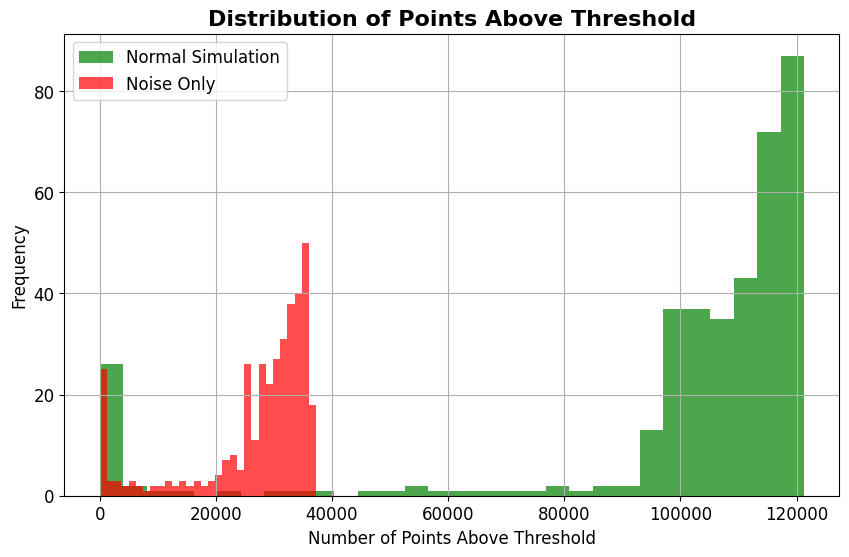

In [266]:
plt.figure(figsize=(10, 6))
plt.hist(CS_above_threshold, bins=30, alpha=0.7, label='Normal Simulation', color='g')
plt.hist(noise_above_threshold, bins=30, alpha=0.7, label='Noise Only', color='r')
#plt.axvline(x=threshold, color='red', linestyle='--', label='Threshold (130 pM)')
plt.xlabel('Number of Points Above Threshold')
plt.ylabel('Frequency')
plt.title('Distribution of Points Above Threshold', fontsize=16,fontweight ='bold')
plt.legend()
plt.grid(True)
plt.show()


/tmp/ipykernel_2656727/1677297546.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([CS_above_threshold, noise_above_threshold], labels=['Normal', 'Noise Only'])


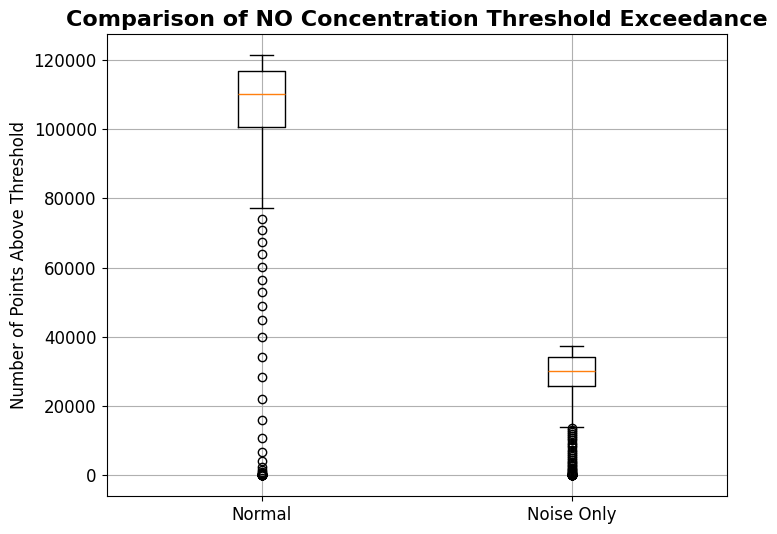

In [267]:

plt.figure(figsize=(8, 6))
plt.boxplot([CS_above_threshold, noise_above_threshold], labels=['Normal', 'Noise Only'])
plt.ylabel('Number of Points Above Threshold')
plt.title('Comparison of NO Concentration Threshold Exceedance', fontsize=16,fontweight ='bold')
plt.grid(True)
plt.show()


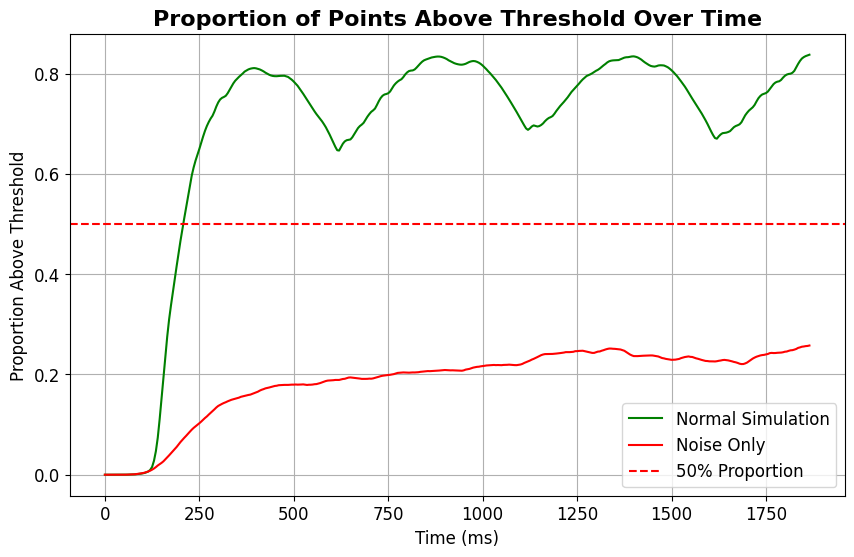

In [ ]:

time = np.arange(0, t, 5) 
plt.figure(figsize=(10, 6))
plt.plot(time, CS_proportion, label='Normal Simulation', color='g')
plt.plot(time, noise_proportion, label='Noise Only', color='r')
#plt.axhline(y=0.5, color='red', linestyle='--', label='50% Proportion')
plt.xlabel('Time (ms)')
plt.ylabel('Proportion Above Threshold')
plt.title('Proportion of Points Above Threshold Over Time', fontsize=16,fontweight ='bold')
plt.legend()
plt.grid(True)
plt.show()

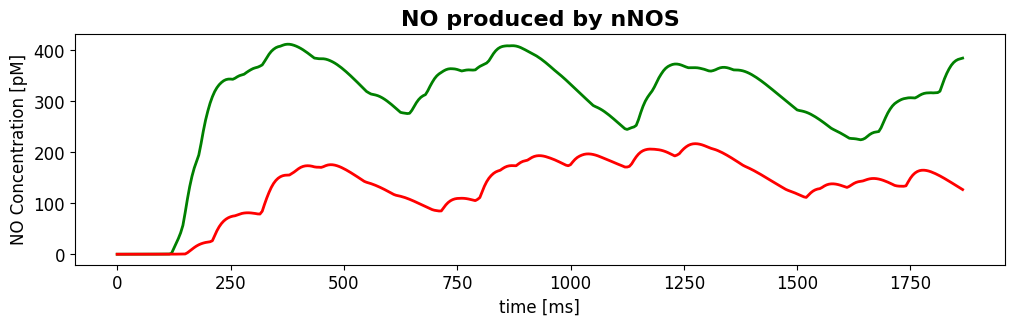

In [269]:
plt.rcParams.update({'font.size': 12},)
plt.figure(figsize=(12,3))
plt.plot(np.arange(0,t,5),concentration_plot_CS, 'g', linewidth=2)
plt.plot(np.arange(0,t,5),concentration_plot_noise, 'r', linewidth=2)
plt.xlabel('time [ms]')
plt.ylabel('NO Concentration [pM]')
#plt.grid(visible=True)
plt.title('NO produced by nNOS', fontsize=16,fontweight ='bold')
#plt.savefig('vm_neuron.png')
plt.show()

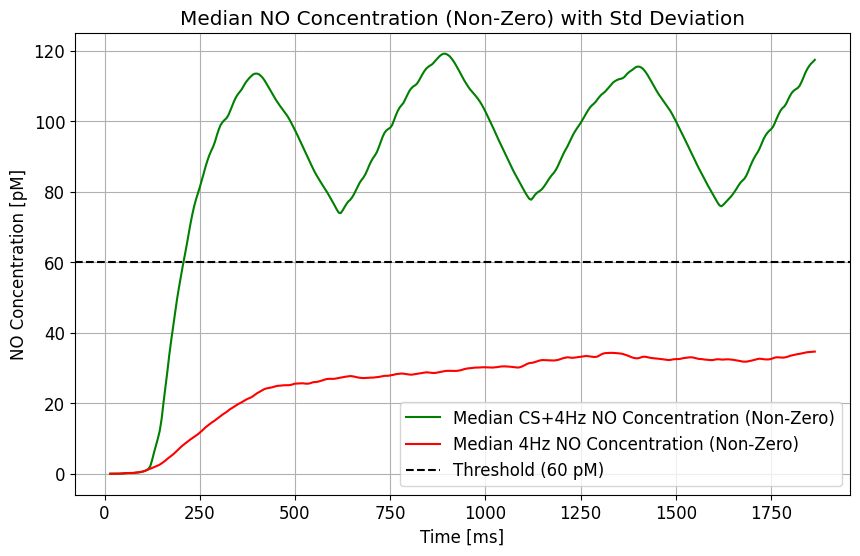

In [270]:
# Initialize lists for storing results
CS_filtered_median = []
CS_filtered_std = []
CS_filtered_time = []
noise_filtered_median = []
noise_filtered_std = []
noise_filtered_time = []

# Loop through each time point and compute stats
for i in range(concentration_CS_clusters.shape[0]):
    non_zero_values = concentration_CS_clusters[i][concentration_CS_clusters[i] > 0]  # Filter out zeros
    if len(non_zero_values) > 0:  # Only process if there are non-zero values
        CS_filtered_median.append(np.median(non_zero_values))  # Median of non-zero values
        CS_filtered_std.append(np.std(non_zero_values))        # Std of non-zero values
        CS_filtered_time.append(time[i])                      # Save corresponding time
    non_zero_values = concentration_noise_clusters[i][concentration_noise_clusters[i] > 0]  # Filter out zeros
    if len(non_zero_values) > 0:  # Only process if there are non-zero values
        noise_filtered_median.append(np.median(non_zero_values))  # Median of non-zero values
        noise_filtered_std.append(np.std(non_zero_values))        # Std of non-zero values
        noise_filtered_time.append(time[i])
# Convert lists to numpy arrays for plotting
CS_filtered_median = np.array(CS_filtered_median)
CS_filtered_std = np.array(CS_filtered_std)
CS_filtered_time = np.array(CS_filtered_time)

noise_filtered_median = np.array(noise_filtered_median)
noise_filtered_std = np.array(noise_filtered_std)
noise_filtered_time = np.array(noise_filtered_time)

step_size = 100 // 5  # Convert 50 ms to the number of steps
CS_downsampled_times = CS_filtered_time[::step_size]
CS_downsampled_std = CS_filtered_std[::step_size]

noise_downsampled_times = noise_filtered_time[::step_size]
noise_downsampled_std = noise_filtered_std[::step_size]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(CS_filtered_time, CS_filtered_median, label='Median CS+4Hz NO Concentration (Non-Zero)', color='green')
plt.plot(noise_filtered_time, noise_filtered_median, label='Median 4Hz NO Concentration (Non-Zero)', color='red')
plt.axhline(y=threshold, color='black', linestyle='--', label=f'Threshold ({threshold} pM)')

# Add labels and legend
plt.xlabel('Time [ms]')
plt.ylabel('NO Concentration [pM]')
plt.title('Median NO Concentration (Non-Zero) with Std Deviation')
plt.legend()
plt.grid(True)
plt.show()